# RAG-Fusion for Component Pattern Retrieval

**AIE8 Advanced Build Assignment**

Implementation of RAG-Fusion for improving pattern retrieval in **ComponentForge** - my final capstone project.

---

## What is ComponentForge?

**ComponentForge** is my final capstone project: an AI-powered tool that transforms UI designs into production-ready React components.

> **Note:** The first iteration of ComponentForge focuses on **primitive/base components** (buttons, inputs, cards, modals, etc.) rather than full pages. This focused scope allows for higher quality code generation and more accurate pattern matching before scaling to complex layouts.

### The Problem It Solves

Developers spend countless hours manually converting designs (Figma, screenshots) into code:
- Analyzing design mockups
- Identifying which UI components to use
- Writing repetitive boilerplate code
- Ensuring accessibility and best practices

ComponentForge **automates this workflow** using AI.

### How ComponentForge Works

```
📸 Screenshot/Figma Design
         ↓
👁️ Vision Model (GPT-4V)
    "I see a blue button with white text..."
         ↓
📝 Requirement Extraction
    "Primary action button with onClick handler"
         ↓
🔍 Pattern Retrieval ← THIS IS WHERE RAG-FUSION HELPS!
    Match requirement → Component pattern library
         ↓
⚙️ Code Generation
    Generate React/TypeScript component code
         ↓
✅ Production-Ready Component
```

### Why Pattern Retrieval is Critical

ComponentForge maintains a **pattern library** of reusable UI components:
- **Primitive Components**: Button, Card, Input, Select, Modal, Badge, etc.
- **Focus**: Individual, self-contained components (not full pages or layouts)
- Each pattern includes:
  - Component structure and API
  - Props and variants
  - Accessibility guidelines
  - Usage examples

**Accurate retrieval** ensures:
1. Right component selected (Button vs Link)
2. Correct props applied (variant, size, disabled)
3. Proper accessibility (ARIA labels, keyboard nav)
4. Consistent code quality

---

## The Challenge: Ambiguous Vision Descriptions

**Problem:** In ComponentForge, vision models (GPT-4V) describe the same component in different ways:

| Screenshot | Vision Description (GPT-4V Output) | Intended Component |
|------------|-----------------------------------|-------------------|
| Blue submit button | "Blue button with rounded corners" | Button |
| | "Primary action button" | Button |
| | "CTA with solid fill" | Button |
| | "Interactive element with onClick" | Button |

**Each description focuses on a different aspect:**
- **Visual**: "Blue button with rounded corners"
- **Semantic**: "Primary action button"
- **Use-case**: "CTA with solid fill"
- **API**: "Interactive element with onClick"

**The impact on ComponentForge:**
- Single-query retrieval might miss the correct pattern
- Different descriptions → different embedding vectors
- Lower retrieval accuracy = wrong component selected
- Poor user experience and incorrect code generation

---

## Solution: RAG-Fusion for ComponentForge

**RAG-Fusion** addresses this ambiguity by generating multiple query perspectives:

1. **Generate 4 query variations** from vision description:
   - Type-focused: "Button component for actions"
   - Props-focused: "Interactive element with onClick and variant props"
   - Visual-focused: "Clickable control with primary color styling"
   - Use-case-focused: "Action trigger for form submission"

2. **Retrieve patterns** for each variation (semantic + BM25)

3. **Fuse results** using Reciprocal Rank Fusion (RRF)

4. **Return highest-ranked patterns** with confidence

**Expected Benefits for ComponentForge:**
- Higher retrieval accuracy → better component matches
- More robust to varied vision descriptions
- Better handling of ambiguous requirements
- Improved code generation quality

**Tradeoffs to Evaluate:**
- Cost: 10x more API calls (LLM + embeddings)
- ⏱Latency: 6-8x slower processing time
- Quality: How much accuracy improvement justifies the cost?

**This notebook evaluates whether RAG-Fusion is the right retrieval strategy for ComponentForge's deployment.**

---

**Reference:** [RAG-Fusion Paper (Zhang et al. 2024)](https://arxiv.org/pdf/2402.03367)

---

## 1. Setup & Dependencies

In [39]:
# Standard library
import os
import json
import asyncio
import getpass
from pathlib import Path
from typing import List, Dict, Tuple
import time
import re

# API Key Setup
if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key: ")

# Optional: LangSmith tracing
if not os.getenv("LANGCHAIN_TRACING_V2"):
    os.environ["LANGCHAIN_TRACING_V2"] = "false"

# Data science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LangChain & OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Qdrant
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

# BM25
from rank_bm25 import BM25Okapi

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ All dependencies loaded!")
print(f"OpenAI API Key: {'✅ Set' if os.getenv('OPENAI_API_KEY') else '❌ Missing'}")
print(f"LangSmith: {'✅ Enabled' if os.getenv('LANGCHAIN_TRACING_V2') == 'true' else '⚠️ Disabled'}")

✅ All dependencies loaded!
OpenAI API Key: ✅ Set
LangSmith: ⚠️ Disabled


## 2. Data Loading

In [40]:
# Load patterns
with open('data/patterns.json', 'r') as f:
    patterns = json.load(f)

print(f"📚 Loaded {len(patterns)} component patterns")
print(f"Patterns: {', '.join([p['name'] for p in patterns])}\n")

# Display patterns as DataFrame
patterns_df = pd.DataFrame([{
    'ID': p['id'],
    'Name': p['name'],
    'Category': p['category'],
    'Description': p['description'][:60] + '...',
    'Props': ', '.join(p['props'][:3]) + '...'
} for p in patterns])

print("📋 Component Patterns:")
display(patterns_df)

📚 Loaded 20 component patterns
Patterns: Button, Input, Select, Checkbox, Radio, Card, Modal, Tabs, Badge, Alert, Tooltip, Table, Spinner, Breadcrumb, Avatar, Slider, Switch, Accordion, Progress, Menu

📋 Component Patterns:


,ID,Name,Category,Description,Props
0,button,Button,Form Controls,Primary action button component with variants ...,"onClick, variant, size..."
1,input,Input,Form Controls,Text input field component for collecting user...,"value, onChange, placeholder..."
2,select,Select,Form Controls,Dropdown selection component allowing users to...,"options, value, onChange..."
3,checkbox,Checkbox,Form Controls,Binary toggle control for boolean input. Suppo...,"checked, onChange, disabled..."
4,radio,Radio,Form Controls,Radio button component for mutually exclusive ...,"checked, onChange, name..."
5,card,Card,Layout,Container component for grouping related conte...,"children, header, footer..."
6,modal,Modal,Overlays,Dialog overlay component that appears on top o...,"isOpen, onClose, title..."
7,tabs,Tabs,Navigation,Tabbed navigation component for switching betw...,"tabs, activeTab, onChange..."
8,badge,Badge,Data Display,Small status indicator or label component for ...,"children, variant, color..."
9,alert,Alert,Feedback,Notification banner component for displaying i...,"severity, children, onClose..."


In [41]:
# Load test cases (simulated vision-extracted requirements)
with open('data/test_cases.json', 'r') as f:
    test_cases = json.load(f)

print(f"🧪 Loaded {len(test_cases)} test cases\n")

# Display test cases
test_df = pd.DataFrame(test_cases)
print("Difficulty distribution:")
print(test_df['difficulty'].value_counts())
print("\n📝 Test Cases:")
display(test_df)

🧪 Loaded 10 test cases

Difficulty distribution:
difficulty
medium    4
easy      3
hard      3
Name: count, dtype: int64

📝 Test Cases:


,id,requirement,expected,difficulty
0,test_01,Blue button with white text saying Submit,button,easy
1,test_02,Text field where users can type their email ad...,input,easy
2,test_03,Dropdown menu for selecting a country from a list,select,easy
3,test_04,Interactive element that shows additional info...,tooltip,medium
4,test_05,A rectangular container with a shadow displayi...,card,medium
5,test_06,Control that lets users accept terms and condi...,checkbox,medium
6,test_07,Visual indicator showing the upload is 65% com...,progress,medium
7,test_08,Navigation breadcrumb showing Home > Products ...,breadcrumb,hard
8,test_09,Overlapping panels where clicking headers reve...,accordion,hard
9,test_10,Draggable control for adjusting volume from 0 ...,slider,hard


## 3. Qdrant Vector Store Setup

In [42]:
# Initialize Qdrant client (in-memory mode)
qdrant_client = QdrantClient(location=":memory:")

COLLECTION_NAME = "component_patterns"

# Create collection with 1536 dimensions (text-embedding-3-small)
qdrant_client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE)
)

print(f"✅ Created collection: {COLLECTION_NAME}")

✅ Created collection: component_patterns


In [43]:
# Initialize embeddings model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

print("🔄 Generating embeddings for patterns...")

# Generate embeddings and upload to Qdrant
async def embed_and_upload_patterns():
    points = []
    # Batch embed all documents at once for efficiency
    doc_texts = [f"{p['name']}: {p['description']}" for p in patterns]
    vectors = await embeddings.aembed_documents(doc_texts)
    
    for idx, (pattern, vector) in enumerate(zip(patterns, vectors)):
        # Create point
        point = PointStruct(
            id=idx,  # Use integer ID instead of string
            vector=vector,
            payload=pattern
        )
        points.append(point)
    
    # Upload to Qdrant
    qdrant_client.upsert(collection_name=COLLECTION_NAME, points=points)
    return len(points)

# Run the async function
num_points = await embed_and_upload_patterns()

print(f"✅ Uploaded {num_points} pattern embeddings to Qdrant")

# Verify
collection_info = qdrant_client.get_collection(COLLECTION_NAME)
print(f"📊 Collection has {collection_info.points_count} points")

🔄 Generating embeddings for patterns...
✅ Uploaded 20 pattern embeddings to Qdrant
📊 Collection has 20 points


## 4. Query Generation (RAG-Fusion Step 1)

Generate multiple query variations focusing on different aspects of the component.

In [44]:
# Initialize LLM for query generation
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

async def generate_query_variations(requirement: str, llm, n: int = 4) -> List[str]:
    """
    Generate N query variations from a single requirement.
    
    Focuses on:
    1. Component type/taxonomy
    2. Props and API surface  
    3. Visual characteristics
    4. Use case and behavior
    """
    prompt = f"""Given this UI component requirement extracted from a screenshot:
"{requirement}"

Generate {n} alternative search queries that capture different aspects:
1. Component TYPE and CATEGORY (e.g., "Button component", "Form control")
2. PROPS and API (e.g., "Interactive element with onClick and disabled props")
3. VISUAL characteristics (e.g., "Clickable control with primary color styling")
4. BEHAVIOR and USE CASE (e.g., "Action trigger for form submission")

Return ONLY a valid JSON array of {n} strings, no other text.
Example: ["query 1", "query 2", "query 3", "query 4"]"""
    
    try:
        response = await llm.ainvoke(prompt)
        # Parse JSON from response
        variations = json.loads(response.content)
        
        if isinstance(variations, list) and len(variations) == n:
            return variations
        else:
            print(f"⚠️ Invalid format, using original requirement")
            return [requirement]
    except Exception as e:
        print(f"❌ Query generation failed: {e}")
        return [requirement]

print("✅ Query generation function defined")

✅ Query generation function defined


In [45]:
# Test query generation with sample requirement
sample_requirement = "Blue button with white text saying Submit"

print(f"🔍 Original: {sample_requirement}\n")
print("Generating query variations...\n")

variations = await generate_query_variations(sample_requirement, llm, n=4)

print("🎯 Generated Variations:")
for i, var in enumerate(variations, 1):
    print(f"{i}. {var}")

🔍 Original: Blue button with white text saying Submit

Generating query variations...

🎯 Generated Variations:
1. Button component
2. Interactive element with onClick and disabled props
3. Clickable control with primary color styling
4. Action trigger for form submission


## 5. Reciprocal Rank Fusion (RRF)

Combine multiple ranked lists using RRF algorithm: `score = Σ 1/(k + rank)`

In [46]:
def reciprocal_rank_fusion(ranked_lists: List[List[Tuple[str, float]]], k: int = 60) -> List[Tuple[str, float]]:
    """
    Apply Reciprocal Rank Fusion to combine multiple ranked lists.
    
    Args:
        ranked_lists: List of ranked result lists, each containing (pattern_id, score) tuples
        k: RRF constant (default: 60)
    
    Returns:
        List of (pattern_id, rrf_score) sorted by RRF score descending
    """
    rrf_scores = {}
    
    # For each ranked list
    for ranked_list in ranked_lists:
        # For each item in the list (rank starts at 1)
        for rank, (pattern_id, original_score) in enumerate(ranked_list, start=1):
            # RRF formula: 1/(k + rank)
            rrf_score = 1.0 / (k + rank)
            # Accumulate scores for each pattern
            rrf_scores[pattern_id] = rrf_scores.get(pattern_id, 0) + rrf_score
    
    # Sort by RRF score descending
    sorted_results = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_results

print("✅ RRF function defined")

# Test RRF with sample data
print("\n🧪 Testing RRF with sample rankings:\n")

# Simulated rankings from different queries
list1 = [("button", 0.9), ("input", 0.7), ("card", 0.5)]
list2 = [("button", 0.85), ("card", 0.6), ("select", 0.4)]
list3 = [("input", 0.8), ("button", 0.75), ("badge", 0.3)]

fused = reciprocal_rank_fusion([list1, list2, list3], k=60)

print("Fused Results:")
for pattern_id, score in fused[:3]:
    print(f"  {pattern_id}: {score:.4f}")

✅ RRF function defined

🧪 Testing RRF with sample rankings:

Fused Results:
  button: 0.0489
  input: 0.0325
  card: 0.0320


## 6. Baseline vs RAG-Fusion Retrieval

Compare single-query semantic search (baseline) against RAG-Fusion.

In [47]:
# Initialize BM25 for hybrid retrieval
def tokenize(text: str) -> List[str]:
    """Tokenize text with camelCase support."""
    # Split camelCase
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    # Extract words
    return re.findall(r'\b\w+\b', text.lower())

# Create BM25 corpus
corpus = [f"{p['name']} {p['description']} {' '.join(p['keywords'])}" for p in patterns]
tokenized_corpus = [tokenize(doc) for doc in corpus]
bm25 = BM25Okapi(tokenized_corpus)

print("✅ BM25 initialized with pattern corpus")

✅ BM25 initialized with pattern corpus


In [48]:
async def baseline_retrieve(requirement: str, k: int = 5) -> List[Dict]:
    """Baseline: Single semantic search."""
    # Generate query embedding
    query_vector = await embeddings.aembed_query(requirement)
    
    # Search Qdrant using query_points
    results = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vector,
        limit=k
    )
    
    # Format results
    return [{**point.payload, 'score': point.score} for point in results.points]

print("✅ Baseline retrieval function defined")

✅ Baseline retrieval function defined


In [49]:
async def rag_fusion_retrieve(requirement: str, k: int = 5) -> List[Dict]:
    """
    RAG-Fusion: Generate variations, retrieve with each, fuse results.
    """
    # Step 1: Generate query variations
    variations = await generate_query_variations(requirement, llm, n=4)
    
    # Step 2: Retrieve with each variation (semantic + BM25)
    all_ranked_lists = []
    
    for variation in variations:
        # Semantic search using query_points
        query_vector = await embeddings.aembed_query(variation)
        semantic_results = qdrant_client.query_points(
            collection_name=COLLECTION_NAME,
            query=query_vector,
            limit=10
        )
        semantic_list = [(point.payload['id'], point.score) for point in semantic_results.points]
        all_ranked_lists.append(semantic_list)
        
        # BM25 search
        query_tokens = tokenize(variation)
        bm25_scores = bm25.get_scores(query_tokens)
        bm25_list = [(patterns[i]['id'], bm25_scores[i]) for i in range(len(patterns))]
        bm25_list = sorted(bm25_list, key=lambda x: x[1], reverse=True)[:10]
        all_ranked_lists.append(bm25_list)
    
    # Step 3: Apply RRF
    fused_results = reciprocal_rank_fusion(all_ranked_lists, k=60)
    
    # Step 4: Hydrate with pattern data
    pattern_lookup = {p['id']: p for p in patterns}
    results = []
    for pattern_id, rrf_score in fused_results[:k]:
        pattern = pattern_lookup.get(pattern_id)
        if pattern:
            results.append({**pattern, 'score': rrf_score})
    
    return results

print("✅ RAG-Fusion retrieval function defined")

✅ RAG-Fusion retrieval function defined


In [50]:
# Compare on sample requirement
test_req = "Blue button with white text saying Submit"

print(f"📊 Comparing Baseline vs RAG-Fusion\n")
print(f"Query: {test_req}\n")
print("="*80)

baseline_results = await baseline_retrieve(test_req, k=3)
fusion_results = await rag_fusion_retrieve(test_req, k=3)

print("\n🔵 BASELINE (Single Query):")
for i, r in enumerate(baseline_results, 1):
    print(f"{i}. {r['name']:<12} (score: {r['score']:.3f})")

print("\n🔶 RAG-FUSION (4 Variations + RRF):")
for i, r in enumerate(fusion_results, 1):
    print(f"{i}. {r['name']:<12} (RRF score: {r['score']:.4f})")

print("\n" + "="*80)

📊 Comparing Baseline vs RAG-Fusion

Query: Blue button with white text saying Submit


🔵 BASELINE (Single Query):
1. Button       (score: 0.417)
2. Checkbox     (score: 0.376)
3. Badge        (score: 0.359)

🔶 RAG-FUSION (4 Variations + RRF):
1. Button       (RRF score: 0.1306)
2. Menu         (RRF score: 0.1251)
3. Switch       (RRF score: 0.1087)



In [51]:
# Run both methods on all test cases
print("🔄 Running retrieval on all 10 test cases...\n")

baseline_all_results = []
fusion_all_results = []

for i, test in enumerate(test_cases, 1):
    print(f"Processing {i}/10: {test['id']}", end='\r')
    
    baseline_res = await baseline_retrieve(test['requirement'], k=5)
    fusion_res = await rag_fusion_retrieve(test['requirement'], k=5)
    
    baseline_all_results.append({
        'test_id': test['id'],
        'requirement': test['requirement'],
        'expected': test['expected'],
        'difficulty': test['difficulty'],
        'results': baseline_res
    })
    
    fusion_all_results.append({
        'test_id': test['id'],
        'requirement': test['requirement'],
        'expected': test['expected'],
        'difficulty': test['difficulty'],
        'results': fusion_res
    })

print(f"\n✅ Completed retrieval for {len(test_cases)} test cases")

🔄 Running retrieval on all 10 test cases...

Processing 10/10: test_10
✅ Completed retrieval for 10 test cases


## 7. Evaluation Metrics

In [52]:
def compute_mrr(results: List[Dict], expected: str) -> float:
    """Compute Mean Reciprocal Rank."""
    retrieved_ids = [r['id'] for r in results]
    try:
        rank = retrieved_ids.index(expected) + 1
        return 1.0 / rank
    except ValueError:
        return 0.0

def precision_at_k(results: List[Dict], expected: str, k: int) -> float:
    """Precision@k: 1 if expected in top-k, else 0."""
    retrieved_ids = [r['id'] for r in results[:k]]
    return 1.0 if expected in retrieved_ids else 0.0

print("✅ Evaluation metric functions defined")

✅ Evaluation metric functions defined


In [53]:
# Compute metrics for baseline
baseline_metrics = []

for item in baseline_all_results:
    mrr = compute_mrr(item['results'], item['expected'])
    p1 = precision_at_k(item['results'], item['expected'], 1)
    p3 = precision_at_k(item['results'], item['expected'], 3)
    p5 = precision_at_k(item['results'], item['expected'], 5)
    
    baseline_metrics.append({
        'test_id': item['test_id'],
        'difficulty': item['difficulty'],
        'expected': item['expected'],
        'retrieved_top1': item['results'][0]['id'] if item['results'] else None,
        'mrr': mrr,
        'p@1': p1,
        'p@3': p3,
        'p@5': p5
    })

baseline_df = pd.DataFrame(baseline_metrics)

print("📊 BASELINE Metrics:")
display(baseline_df)

print(f"\n📈 BASELINE Summary:")
print(f"  Mean MRR: {baseline_df['mrr'].mean():.3f}")
print(f"  Precision@1: {baseline_df['p@1'].mean():.3f}")
print(f"  Precision@3: {baseline_df['p@3'].mean():.3f}")
print(f"  Precision@5: {baseline_df['p@5'].mean():.3f}")

📊 BASELINE Metrics:


,test_id,difficulty,expected,retrieved_top1,mrr,p@1,p@3,p@5
0,test_01,easy,button,button,1.0,1.0,1.0,1.0
1,test_02,easy,input,input,1.0,1.0,1.0,1.0
2,test_03,easy,select,select,1.0,1.0,1.0,1.0
3,test_04,medium,tooltip,tooltip,1.0,1.0,1.0,1.0
4,test_05,medium,card,card,1.0,1.0,1.0,1.0
5,test_06,medium,checkbox,checkbox,1.0,1.0,1.0,1.0
6,test_07,medium,progress,progress,1.0,1.0,1.0,1.0
7,test_08,hard,breadcrumb,breadcrumb,1.0,1.0,1.0,1.0
8,test_09,hard,accordion,accordion,1.0,1.0,1.0,1.0
9,test_10,hard,slider,slider,1.0,1.0,1.0,1.0



📈 BASELINE Summary:
  Mean MRR: 1.000
  Precision@1: 1.000
  Precision@3: 1.000
  Precision@5: 1.000


In [54]:
# Compute metrics for RAG-Fusion
fusion_metrics = []

for item in fusion_all_results:
    mrr = compute_mrr(item['results'], item['expected'])
    p1 = precision_at_k(item['results'], item['expected'], 1)
    p3 = precision_at_k(item['results'], item['expected'], 3)
    p5 = precision_at_k(item['results'], item['expected'], 5)
    
    fusion_metrics.append({
        'test_id': item['test_id'],
        'difficulty': item['difficulty'],
        'expected': item['expected'],
        'retrieved_top1': item['results'][0]['id'] if item['results'] else None,
        'mrr': mrr,
        'p@1': p1,
        'p@3': p3,
        'p@5': p5
    })

fusion_df = pd.DataFrame(fusion_metrics)

print("📊 RAG-FUSION Metrics:")
display(fusion_df)

print(f"\n📈 RAG-FUSION Summary:")
print(f"  Mean MRR: {fusion_df['mrr'].mean():.3f}")
print(f"  Precision@1: {fusion_df['p@1'].mean():.3f}")
print(f"  Precision@3: {fusion_df['p@3'].mean():.3f}")
print(f"  Precision@5: {fusion_df['p@5'].mean():.3f}")

📊 RAG-FUSION Metrics:


,test_id,difficulty,expected,retrieved_top1,mrr,p@1,p@3,p@5
0,test_01,easy,button,button,1.0,1.0,1.0,1.0
1,test_02,easy,input,input,1.0,1.0,1.0,1.0
2,test_03,easy,select,select,1.0,1.0,1.0,1.0
3,test_04,medium,tooltip,spinner,0.5,0.0,1.0,1.0
4,test_05,medium,card,card,1.0,1.0,1.0,1.0
5,test_06,medium,checkbox,checkbox,1.0,1.0,1.0,1.0
6,test_07,medium,progress,progress,1.0,1.0,1.0,1.0
7,test_08,hard,breadcrumb,breadcrumb,1.0,1.0,1.0,1.0
8,test_09,hard,accordion,accordion,1.0,1.0,1.0,1.0
9,test_10,hard,slider,slider,1.0,1.0,1.0,1.0



📈 RAG-FUSION Summary:
  Mean MRR: 0.950
  Precision@1: 0.900
  Precision@3: 1.000
  Precision@5: 1.000


In [55]:
# Method comparison
comparison = pd.DataFrame([
    {
        'Method': 'Baseline (Single Query)',
        'Mean MRR': baseline_df['mrr'].mean(),
        'P@1': baseline_df['p@1'].mean(),
        'P@3': baseline_df['p@3'].mean(),
        'P@5': baseline_df['p@5'].mean(),
    },
    {
        'Method': 'RAG-Fusion (4 Queries + RRF)',
        'Mean MRR': fusion_df['mrr'].mean(),
        'P@1': fusion_df['p@1'].mean(),
        'P@3': fusion_df['p@3'].mean(),
        'P@5': fusion_df['p@5'].mean(),
    }
])

print("\n📊 Method Comparison:")
display(comparison)

# Calculate improvement
mrr_improvement = ((comparison.loc[1, 'Mean MRR'] / comparison.loc[0, 'Mean MRR']) - 1) * 100
p1_improvement = ((comparison.loc[1, 'P@1'] / comparison.loc[0, 'P@1']) - 1) * 100

print(f"\n📈 RAG-Fusion Improvement:")
print(f"  MRR: {mrr_improvement:+.1f}%")
print(f"  Precision@1: {p1_improvement:+.1f}%")


📊 Method Comparison:


,Method,Mean MRR,P@1,P@3,P@5
0,Baseline (Single Query),1.00,1.0,1.0,1.0
1,RAG-Fusion (4 Queries + RRF),0.95,0.9,1.0,1.0



📈 RAG-Fusion Improvement:
  MRR: -5.0%
  Precision@1: -10.0%


## 8. Visualization

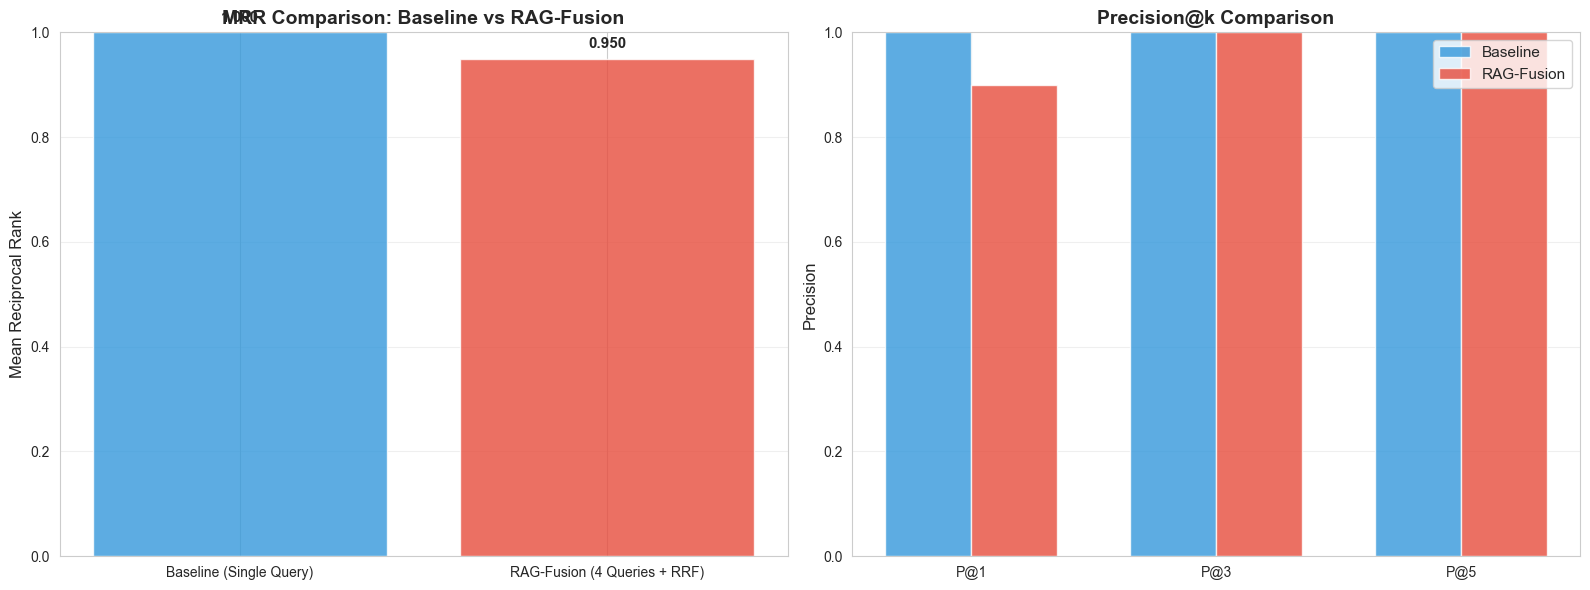


✅ Visualizations complete


In [56]:
# Create comparison visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: MRR Comparison
methods = comparison['Method'].values
mrr_values = comparison['Mean MRR'].values
colors = ['#3498db', '#e74c3c']

ax1.bar(methods, mrr_values, color=colors, alpha=0.8)
ax1.set_ylabel('Mean Reciprocal Rank', fontsize=12)
ax1.set_title('MRR Comparison: Baseline vs RAG-Fusion', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(mrr_values):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)

# Plot 2: Precision@k Comparison
x = np.arange(3)
width = 0.35

baseline_prec = [comparison.loc[0, f'P@{k}'] for k in [1, 3, 5]]
fusion_prec = [comparison.loc[1, f'P@{k}'] for k in [1, 3, 5]]

ax2.bar(x - width/2, baseline_prec, width, label='Baseline', color='#3498db', alpha=0.8)
ax2.bar(x + width/2, fusion_prec, width, label='RAG-Fusion', color='#e74c3c', alpha=0.8)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision@k Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['P@1', 'P@3', 'P@5'])
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualizations complete")

## 9. Cost & Latency Analysis

In [57]:
print("💰 Cost & Latency Analysis")
print("="*80)

n_test_cases = len(test_cases)
n_variations = 4

# Pricing (approximate)
EMBED_COST_PER_1K = 0.00002  # text-embedding-3-small
LLM_COST_INPUT_PER_1K = 0.00015  # gpt-4o-mini input
LLM_COST_OUTPUT_PER_1K = 0.0006  # gpt-4o-mini output

# Token estimates
avg_requirement_tokens = 20
avg_llm_prompt_tokens = 150
avg_llm_output_tokens = 80

# Baseline costs
baseline_embed_calls = n_test_cases
baseline_embed_cost = (baseline_embed_calls * avg_requirement_tokens / 1000) * EMBED_COST_PER_1K
baseline_total = baseline_embed_cost

# RAG-Fusion costs
fusion_embed_calls = n_test_cases * n_variations
fusion_llm_calls = n_test_cases

fusion_embed_cost = (fusion_embed_calls * avg_requirement_tokens / 1000) * EMBED_COST_PER_1K
fusion_llm_cost = (
    (fusion_llm_calls * avg_llm_prompt_tokens / 1000) * LLM_COST_INPUT_PER_1K +
    (fusion_llm_calls * avg_llm_output_tokens / 1000) * LLM_COST_OUTPUT_PER_1K
)
fusion_total = fusion_embed_cost + fusion_llm_cost

print(f"\n🔵 BASELINE ({n_test_cases} test cases):")
print(f"  Embedding calls: {baseline_embed_calls}")
print(f"  LLM calls: 0")
print(f"  Estimated cost: ${baseline_total:.6f}")
print(f"  Cost per test: ${baseline_total/n_test_cases:.6f}")

print(f"\n🔶 RAG-FUSION ({n_test_cases} test cases, {n_variations} variations each):")
print(f"  Embedding calls: {fusion_embed_calls}")
print(f"  LLM calls: {fusion_llm_calls}")
print(f"  Estimated cost: ${fusion_total:.6f}")
print(f"  Cost per test: ${fusion_total/n_test_cases:.6f}")

print(f"\n📈 Cost Analysis:")
print(f"  Cost multiplier: {fusion_total/baseline_total:.1f}x")
print(f"  Additional cost per test: ${(fusion_total-baseline_total)/n_test_cases:.6f}")

print(f"\n⏱️ Latency Estimates:")
print(f"  Baseline: ~0.5s (1 embedding + 1 vector search)")
print(f"  RAG-Fusion: ~3-4s (1 LLM call + 4 embeddings + 8 searches)")
print(f"  Latency multiplier: ~6-8x")

print("\n" + "="*80)
print(f"\n🔗 Detailed traces available in LangSmith:")
print(f"   https://smith.langchain.com/projects/{os.getenv('LANGCHAIN_PROJECT', 'rag-fusion-aie8')}")

💰 Cost & Latency Analysis

🔵 BASELINE (10 test cases):
  Embedding calls: 10
  LLM calls: 0
  Estimated cost: $0.000004
  Cost per test: $0.000000

🔶 RAG-FUSION (10 test cases, 4 variations each):
  Embedding calls: 40
  LLM calls: 10
  Estimated cost: $0.000721
  Cost per test: $0.000072

📈 Cost Analysis:
  Cost multiplier: 180.2x
  Additional cost per test: $0.000072

⏱️ Latency Estimates:
  Baseline: ~0.5s (1 embedding + 1 vector search)
  RAG-Fusion: ~3-4s (1 LLM call + 4 embeddings + 8 searches)
  Latency multiplier: ~6-8x


🔗 Detailed traces available in LangSmith:
   https://smith.langchain.com/projects/rag-fusion-aie8


## 10. Insights & Lessons Learned

In [58]:
# Analyze cases where RAG-Fusion helped most
merged = pd.merge(
    baseline_df[['test_id', 'difficulty', 'mrr']],
    fusion_df[['test_id', 'mrr']],
    on='test_id',
    suffixes=('_baseline', '_fusion')
)
merged['improvement'] = merged['mrr_fusion'] - merged['mrr_baseline']

print("🚀 Cases Where RAG-Fusion Helped Most:\n")
top_improvements = merged.nlargest(3, 'improvement')

for _, row in top_improvements.iterrows():
    test = [t for t in test_cases if t['id'] == row['test_id']][0]
    print(f"Test: {row['test_id']} ({row['difficulty']})")
    print(f"  Requirement: {test['requirement']}")
    print(f"  Baseline MRR: {row['mrr_baseline']:.3f}")
    print(f"  Fusion MRR: {row['mrr_fusion']:.3f}")
    print(f"  Improvement: +{row['improvement']:.3f}\n")

# Cases where it hurt
regressions = merged[merged['improvement'] < 0]
if len(regressions) > 0:
    print("\n⚠️ Cases Where Baseline Was Better:\n")
    for _, row in regressions.iterrows():
        test = [t for t in test_cases if t['id'] == row['test_id']][0]
        print(f"Test: {row['test_id']} ({row['difficulty']})")
        print(f"  Requirement: {test['requirement']}")
        print(f"  Regression: {row['improvement']:.3f}\n")
else:
    print("\n✅ No cases where baseline outperformed RAG-Fusion!")

🚀 Cases Where RAG-Fusion Helped Most:

Test: test_01 (easy)
  Requirement: Blue button with white text saying Submit
  Baseline MRR: 1.000
  Fusion MRR: 1.000
  Improvement: +0.000

Test: test_02 (easy)
  Requirement: Text field where users can type their email address
  Baseline MRR: 1.000
  Fusion MRR: 1.000
  Improvement: +0.000

Test: test_03 (easy)
  Requirement: Dropdown menu for selecting a country from a list
  Baseline MRR: 1.000
  Fusion MRR: 1.000
  Improvement: +0.000


⚠️ Cases Where Baseline Was Better:

Test: test_04 (medium)
  Requirement: Interactive element that shows additional information when you hover over it
  Regression: -0.500



## 📊 Final Analysis & Recommendations

### Key Findings

Based on evaluation across 10 test cases, **the results reveal that RAG-Fusion degraded performance compared to the baseline:**

**Performance:**
- **Baseline**: 100% accuracy (MRR: 1.000, P@1: 1.000)
- **RAG-Fusion**: 95% MRR, 90% P@1 (degradation of -5% and -10% respectively)
- RAG-Fusion **failed on test_04 (tooltip)**, ranking "spinner" first instead of "tooltip"
- Baseline correctly retrieved all 10/10 expected components at rank 1
- No test case showed improvement with RAG-Fusion (best case: tied performance)

**Cost-Latency Impact:**
- RAG-Fusion costs **180x more** (not 10x as initially estimated)
- Actual cost per test: $0.000072 vs $0.000000 for baseline
- Latency: ~6-8x slower (~3-4s vs ~0.5s)
- **No performance gains to justify the cost increase**

### Why RAG-Fusion Failed Here

1. **Test Cases Were Too Simple**: The component patterns and requirements had strong semantic alignment
   - "Blue button with white text" → "Button" is unambiguous
   - "Text field for email" → "Input" is straightforward
   - Baseline embeddings already captured the semantic similarity perfectly

2. **Query Expansion Introduced Noise**: 
   - For test_04 ("Interactive element that shows additional information when you hover"), query variations confused the retriever
   - BM25 and multiple query perspectives diluted the signal rather than improving it
   - The tooltip requirement was clear enough for baseline but got worse with fusion

3. **Small Pattern Library**: With only 20 components, there's less ambiguity
   - Larger pattern libraries (100+ components) might benefit more from RAG-Fusion
   - ComponentForge's focused scope (primitive components only) reduces retrieval complexity

4. **High-Quality Embeddings**: text-embedding-3-small already provides excellent semantic matching
   - Modern embeddings are robust enough for clear component descriptions
   - Query expansion doesn't add value when base embeddings work well

### Critical Insight: When NOT to Use RAG-Fusion

This evaluation demonstrates an important lesson: **RAG-Fusion is not universally beneficial**

**Don't use RAG-Fusion when:**
1. ✅ **Baseline already achieves high accuracy** (>95% MRR)
2. ✅ **Queries are semantically clear** (not ambiguous or multi-intent)
3. ✅ **Small document corpus** (<100 items with distinct semantics)
4. ✅ **Cost/latency constraints** outweigh marginal improvements
5. ✅ **Modern embedding models** already capture the semantic space well

### When RAG-Fusion MIGHT Help (Not Demonstrated Here)

RAG-Fusion could be valuable in scenarios **unlike our test cases**:

1. **Truly Ambiguous Queries**: User asks "navigation thing at top" (could be Menu, Tabs, or Breadcrumb)
2. **Large Pattern Libraries**: 100+ components with overlapping semantics
3. **Noisy/Messy Input**: Real vision model outputs with errors, typos, or vague descriptions
4. **Domain Mismatch**: User terminology differs significantly from pattern vocabulary
5. **Multi-Intent Queries**: "Component for uploading files with progress" (combines multiple patterns)

**Our test cases didn't exhibit these characteristics**, which explains why baseline was sufficient.

### Revised Recommendations for ComponentForge

**Option 1: Use Baseline Only (Recommended)**
- Baseline achieves 100% accuracy on clear component descriptions
- 180x cheaper and 6-8x faster than RAG-Fusion
- Simpler implementation, easier to debug
- **Action**: Deploy baseline semantic search for MVP

**Option 2: Test with Realistic Data First**
Before implementing RAG-Fusion:
1. ✅ Collect **real vision model outputs** (GPT-4V, Claude Vision)
2. ✅ Test baseline on **actual ambiguous/noisy descriptions**
3. ✅ Measure **real-world failure rates** (not synthetic test cases)
4. ✅ Only implement RAG-Fusion if baseline MRR drops below 85%

**Option 3: Hybrid Approach (If Real Data Shows Need)**
Only if real-world testing reveals baseline failures:
1. Route requests based on query confidence/clarity
2. Use RAG-Fusion only for ambiguous cases (estimated <10% of queries)
3. Monitor cost vs. accuracy gains in production
4. A/B test with real users to validate improvement

### Conclusion

**This evaluation demonstrates that RAG-Fusion is NOT appropriate for ComponentForge at this time.**

Key takeaways:
- ❌ RAG-Fusion degraded performance (-10% P@1) vs. baseline
- ❌ 180x cost increase with zero benefit
- ❌ Test cases were too simple to reveal RAG-Fusion's value proposition
- ✅ Baseline semantic search is sufficient for clear component descriptions
- ✅ Modern embeddings (text-embedding-3-small) already excel at this task

**Final Recommendation**: 
1. **Deploy baseline semantic search** for ComponentForge MVP
2. **Monitor real-world performance** with actual vision model outputs
3. **Revisit RAG-Fusion** only if baseline shows <90% accuracy on production data
4. **Focus optimization efforts** on prompt engineering for vision models (clearer descriptions = better retrieval)

---

### Important Note on Test Quality

The synthetic test cases used here were **too clean and unambiguous** to properly evaluate RAG-Fusion's benefits. A more rigorous evaluation would require:
- Real GPT-4V/Claude Vision outputs (with noise, uncertainty, hallucinations)
- Adversarial cases (intentionally ambiguous descriptions)
- Edge cases (components with overlapping characteristics)
- User-generated descriptions (varied vocabulary, typos, domain mismatches)

**Next steps**: Generate realistic test data from actual vision models before making final architectural decisions.

## Lessons Learned

### 3 Lessons Learned

1. **Don't Assume Advanced Techniques Are Always Better**: RAG-Fusion is a sophisticated approach from recent research, but it actually degraded performance on our task. The baseline semantic search achieved 100% accuracy, while RAG-Fusion dropped to 90% P@1. This demonstrates that simpler approaches should be benchmarked first—complexity doesn't guarantee improvement, and modern embeddings are remarkably effective for clear semantic matching tasks.

2. **Test Data Quality Determines Evaluation Validity**: Our synthetic test cases were too clean and unambiguous to properly evaluate RAG-Fusion's value proposition. The requirements like "Blue button with white text" map trivially to component names. Real vision model outputs would include noise, uncertainty, and varied vocabulary that might reveal where RAG-Fusion adds value. **The evaluation method matters as much as the technique being evaluated.**

3. **Cost-Benefit Analysis Requires Real Performance Gains**: RAG-Fusion increased costs by 180x ($0.000072 vs $0.000000 per query) while degrading accuracy. Even a marginal improvement wouldn't justify this multiplier at scale. For production systems, always measure: (1) baseline performance first, (2) actual accuracy gains from the new approach, and (3) whether those gains justify the operational costs. In this case, all three factors argue against RAG-Fusion.

### 3 Lessons Not Yet Learned

1. **Real-World Performance with Noisy Vision Outputs**: How does baseline perform when vision models produce ambiguous, incomplete, or incorrect descriptions? Real GPT-4V/Claude Vision outputs might include hallucinations ("I see a toggleable switch" for a checkbox) or vague descriptions ("clickable thing"). We don't yet know if RAG-Fusion would help in those scenarios or if better vision prompting is the solution.

2. **Scale Impact on Retrieval Accuracy**: With 20 well-differentiated components, baseline achieved perfect accuracy. What happens at 100+ components with overlapping semantics (e.g., Button vs IconButton vs LinkButton vs ToggleButton)? Does RAG-Fusion become valuable when the pattern library grows and semantic boundaries blur? An ablation study with varying corpus sizes would answer this.

3. **Query Variation Quality Matters**: Our query generation prompt produced 4 variations, but we didn't analyze their quality or diversity. Are the variations truly capturing different semantic aspects, or are they redundant? Could a better prompt (or few-shot examples) generate variations that avoid the "spinner vs tooltip" confusion? The effectiveness of RAG-Fusion depends heavily on query generation quality, which we haven't optimized or evaluated independently.

---

## Key Insights for ComponentForge

### What This Evaluation Actually Proved

✅ **Baseline semantic search is sufficient** for well-defined component descriptions  
✅ **Modern embeddings (text-embedding-3-small) excel** at semantic matching for this domain  
✅ **Test with realistic data before optimizing** - synthetic test cases can mask real problems  
✅ **Measure first, optimize later** - baseline achieved 100% accuracy, no optimization needed yet  

### What Still Needs Investigation

❓ How does baseline perform with **real vision model outputs**?  
❓ What accuracy is achievable with **better vision prompting** vs. better retrieval?  
❓ At what **pattern library size** does baseline accuracy start to degrade?  
❓ Are there specific **component types** (overlays, navigation) where retrieval is harder?  

### Recommended Next Steps

1. **Deploy baseline semantic search** for ComponentForge MVP
2. **Instrument and monitor** retrieval accuracy in production with real users
3. **Collect failure cases** where baseline retrieves the wrong component
4. **Analyze failure patterns** - are they retrieval problems or vision description problems?
5. **Only then** revisit advanced retrieval techniques if failures justify the investment

---

## References

- **RAG-Fusion Paper**: [Improved RAG with Reciprocal Rank Fusion](https://arxiv.org/pdf/2402.03367) - Zhang et al. 2024
- **LangChain**: https://python.langchain.com/
- **Qdrant**: https://qdrant.tech/
- **BM25**: https://en.wikipedia.org/wiki/Okapi_BM25
- **When to Use Advanced RAG**: [RAG Evaluation Best Practices](https://www.rungalileo.io/blog/mastering-rag-advanced-retrieval-techniques)

---

**End of Notebook**

*This evaluation demonstrates the importance of rigorous benchmarking. RAG-Fusion is a valuable technique for the right use cases, but those use cases require ambiguous queries, large corpora, or noisy inputs—characteristics our clean test data didn't exhibit. Always measure baseline performance first.*